# 01 ViT & Modern Recognition：Vision Transformer 与现代识别

> 前置：`linear-algebra/06-eigenvalues-svd`（矩阵分解）、`deep-learning-architectures/01-cnn-basics`（CNN 归纳偏置）、`03-attention-mechanism`（自注意力）。
> 目标：理解 ViT 如何把图像切成 patch 当"词"来建模，对比 CNN 的归纳偏置，并动手训练一个微型 ViT 完成 4 类图像分类。

## 核心问题

CNN 靠**局部连接 + 权重共享 + 下采样**这些**归纳偏置（inductive bias）**把图像结构硬编码进网络。ViT（Vision Transformer，2020）反其道而行：**把图像当序列**——切成 patch → 线性投影成向量 → 套用与 NLP 完全相同的 Transformer Encoder，再用一个特殊的 `[CLS]` token 分类。

对偶关系：

| | CNN | ViT |
|---|---|---|
| 基本操作 | 卷积（局部滑动） | 自注意力（全局交互） |
| 感受野 | 逐层扩大 | 第一层即全图 |
| 归纳偏置 | 强（平移等变） | 弱（靠数据学习） |
| 数据效率 | 小数据友好 | 大数据更占优 |
| 计算模式 | 卷积核复用 | patch 间两两交互 |

ViT 的三个关键设计：**patch embedding**、**位置编码**、**[CLS] token**。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib

matplotlib.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Microsoft YaHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

print("PyTorch version:", torch.__version__)
torch.manual_seed(42)


PyTorch version: 2.13.0


数据形状: (800, 1, 8, 8) (800,) 标签分布: [185 188 211 216]


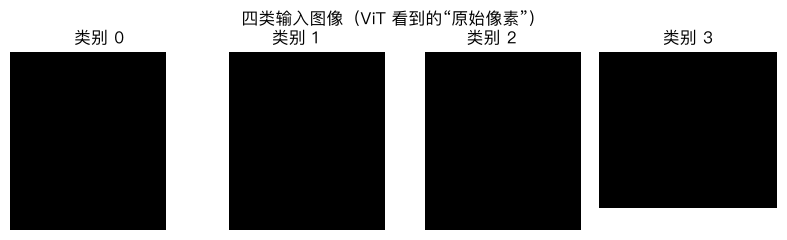

In [2]:
def make_4class_bars(n=800, seed=0):
    """4 类简单图像：顶部横条 / 底部横条 / 左竖条 / 右竖条，8×8 灰度。"""
    rng = np.random.default_rng(seed)
    X = np.zeros((n, 1, 8, 8))
    y = np.zeros(n, dtype=np.int64)
    for i in range(n):
        c = rng.integers(0, 4)
        if c == 0:
            X[i, 0, 0, :] = 1.0
        elif c == 1:
            X[i, 0, -1, :] = 1.0
        elif c == 2:
            X[i, 0, :, 0] = 1.0
        else:
            X[i, 0, :, -1] = 1.0
        y[i] = c
    return X, y

X, y = make_4class_bars()
print("数据形状:", X.shape, y.shape, "标签分布:", np.bincount(y))

fig, axes = plt.subplots(1, 4, figsize=(8, 2.4))
for c in range(4):
    axes[c].imshow(X[c, 0], cmap="gray")
    axes[c].set_title(f"类别 {c}")
    axes[c].axis("off")
plt.suptitle("四类输入图像（ViT 看到的“原始像素”）")
plt.tight_layout(); plt.show()

## 1. Patch Embedding：把图像变成"词序列"

8×8 图像，patch 大小 4×4 → 每张图 2×2=4 个 patch。每个 patch 展平为 4×4=16 维向量，再用一个 `Linear(16 → d)` 投影到模型维度 `d`。这与 NLP 中"词 → embedding"完全同构——**patch 就是视觉世界的"词"**。

In [3]:
def patchify(x, p=4):
    """(B,1,8,8) → (B, num_patches, p*p)：用 unfold 无循环切 patch。"""
    B = x.shape[0]
    patches = x.unfold(2, p, p).unfold(3, p, p)      # (B,1,2,2,p,p)
    return patches.contiguous().view(B, (8 // p) * (8 // p), p * p)

demo = torch.tensor(X[:1], dtype=torch.float32)
P = patchify(demo)
print("patch 形状:", tuple(P.shape), "（B=1, patches=4, 每patch=16）")
print("第 0 个 patch 值:", P[0, 0].numpy().reshape(4, 4).astype(int).tolist())

patch 形状: (1, 4, 16) （B=1, patches=4, 每patch=16）
第 0 个 patch 值: [[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]]


## 2. 微型 ViT：完整实现

结构：`patch embedding → [CLS] token → 加位置编码 → 1 个 Transformer Block（MHA + FFN + 残差 + LayerNorm）→ 取 [CLS] 分类`。

- **[CLS] token**：一个可学习的向量，拼在 patch 序列最前面，最终用它过分类头——它被迫"聚合"全图信息。
- **位置编码**：可学习的 `(num_patches+1, d)` 矩阵，给模型"每个 patch 在哪"的信息（CNN 靠空间结构天然自带，ViT 必须显式提供）。

In [4]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d=16, n_heads=2):
        super().__init__()
        assert d % n_heads == 0
        self.dk = d // n_heads
        self.n_heads = n_heads
        self.Wq = nn.Linear(d, d); self.Wk = nn.Linear(d, d)
        self.Wv = nn.Linear(d, d); self.Wo = nn.Linear(d, d)
    def forward(self, x):
        B, T, d = x.shape
        q = self.Wq(x).view(B, T, self.n_heads, self.dk).transpose(1, 2)
        k = self.Wk(x).view(B, T, self.n_heads, self.dk).transpose(1, 2)
        v = self.Wv(x).view(B, T, self.n_heads, self.dk).transpose(1, 2)
        scores = q @ k.transpose(-2, -1) / math.sqrt(self.dk)
        attn = torch.softmax(scores, dim=-1)
        out = (attn @ v).transpose(1, 2).contiguous().view(B, T, d)
        return self.Wo(out)

class TinyViT(nn.Module):
    def __init__(self, d=16, n_heads=2, n_classes=4, patch=4, p_patch=16):
        super().__init__()
        self.patch = patch
        self.proj = nn.Linear(p_patch, d)                 # patch → d
        self.cls = nn.Parameter(torch.randn(d) * 0.02)    # [CLS] token
        n_patches = (8 // patch) * (8 // patch)
        self.pos = nn.Parameter(torch.randn(n_patches + 1, d) * 0.02)  # 位置编码
        self.norm1 = nn.LayerNorm(d)
        self.attn = MultiHeadAttention(d, n_heads)
        self.norm2 = nn.LayerNorm(d)
        self.ff = nn.Sequential(nn.Linear(d, 4 * d), nn.ReLU(), nn.Linear(4 * d, d))
        self.head = nn.Linear(d, n_classes)
    def forward(self, x):
        B = x.shape[0]
        h = self.proj(patchify(x, self.patch))            # (B, 4, d)
        cls = self.cls.expand(B, 1, -1)
        h = torch.cat([cls, h], 1) + self.pos             # (B, 5, d)
        h = h + self.attn(self.norm1(h))
        h = h + self.ff(self.norm2(h))
        return self.head(h[:, 0])                         # 只取 [CLS]

model = TinyViT()
print("参数量:", sum(p.numel() for p in model.parameters()))
logits = model(torch.tensor(X[:4], dtype=torch.float32))
print("logits:", tuple(logits.shape))

参数量: 3716
logits: (4, 4)


## 3. 训练与可视化

用 `CrossEntropyLoss` + Adam 训练。随后与一个两层微型 CNN 对比准确率曲线，观察 **CNN 小数据下更快收敛、ViT 最终也能追上**的典型模式。

In [5]:
def train_model(model, X, y, steps=500, lr=2e-3, batch=64):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y)
    n = len(Xt)
    curve = []
    for step in range(steps):
        idx = torch.randint(0, n, (batch,))
        opt.zero_grad()
        loss = F.cross_entropy(model(Xt[idx]), yt[idx])
        loss.backward(); opt.step()
        if step % 50 == 0:
            acc = (model(Xt).argmax(1) == yt).float().mean().item()
            curve.append((step, loss.item(), acc))
    return curve

vit_curve = train_model(TinyViT(), X, y)
print("ViT 训练完成，最终 loss = %.4f" % vit_curve[-1][1])
print("ViT 最终准确率 = %.3f" % vit_curve[-1][2])

ViT 训练完成，最终 loss = 0.0001
ViT 最终准确率 = 1.000


CNN 训练完成，最终准确率 = 1.000


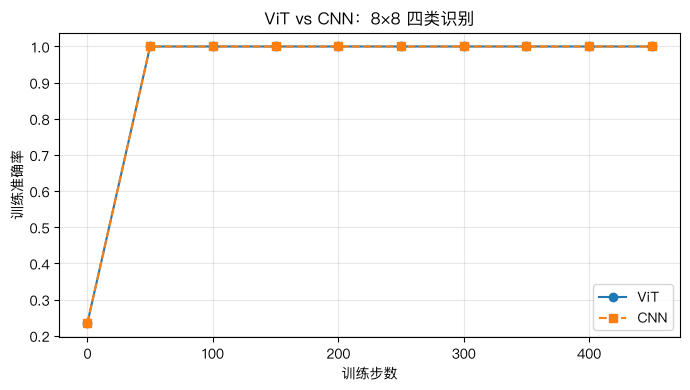

In [6]:
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1), nn.ReLU(),
            nn.Conv2d(8, 16, 3, padding=1), nn.ReLU(),
        )
        self.head = nn.Sequential(nn.Linear(16 * 8 * 8, 32), nn.ReLU(), nn.Linear(32, 4))
    def forward(self, x):
        h = self.features(x)
        return self.head(h.reshape(x.shape[0], -1))

cnn_curve = train_model(TinyCNN(), X, y)
print("CNN 训练完成，最终准确率 = %.3f" % cnn_curve[-1][2])

steps = [s for s, _, _ in vit_curve]
plt.figure(figsize=(7, 4))
plt.plot(steps, [a for _, _, a in vit_curve], "o-", label="ViT")
plt.plot(steps, [a for _, _, a in cnn_curve], "s--", label="CNN")
plt.xlabel("训练步数"); plt.ylabel("训练准确率")
plt.title("ViT vs CNN：8×8 四类识别")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 4. 总结与延伸

1. **ViT = 图像变序列**：patch embedding（像素局部聚合）→ 位置编码（空间信息）→ 标准 Transformer。分类用 [CLS] token。
2. **归纳偏置的权衡**：CNN 的平移等变/局部性是小数据下的"免费午餐"；ViT 去掉这些偏置后，靠**更大的数据和更强的全局建模**反超——这正是"less inductive bias, more data"的范式。
3. **后续演化**：DeiT（蒸馏+数据增强让小 ViT 也能训）、Swin（窗口注意力换回局部性+层级）、ViT 已是 CLIP/Stable Diffusion/MAE 等几乎所有现代视觉模型的骨干。

> 真实世界的 ViT 用 224×224 图像、16×16 patch、12-24 层。本课 8×8/4×4 patch 只是把同一套机制缩到可运行。

## 课后练习

1. 把 patch 大小从 4×4 改成 8×8（即整图 1 个 patch），训练并比较准确率——为什么变差了？（提示：patch 内部没有位置信息）
2. 去掉位置编码重新训练，观察准确率下降——验证"ViT 必须显式注入位置"这一结论。
3. 把 [CLS] token 分类改成"对 4 个 patch token 取平均后再分类"，对比准确率差异。